# Benchmark: Flow over an isothermal plate

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
# import pyvista as pv
# from pyvista import examples

In [ ]:
# Table A.4 - air properties
# at 300 K
# nu = 15.89*10-6; alpha = 22.5*10-6; Pr = 0.707
# at 350 K
# nu = 20.92*10-6; alpha = 29.9*10-6; Pr = 0.700

# temperature inputs
T_inf = 300 # K
T_s = 350 # K
T_f = (T_s + T_inf) / 2 # film temperature
print('T_f = {} K'.format(T_f))

# y = y₁ + [(x - x₁) * (y₂ - y₁)] / (x₂ - x₁) 
rho = 1.1614 + ((T_f - 300) * (0.9950 - 1.1614)) / (350 - 300) # density [kg/m3]
nu = 15.89e-6 + ((T_f - 300) * (20.92e-6 - 15.89e-6)) / (350 - 300) # kinematic visc [m2/s]
alpha = 22.5e-6 + ((T_f - 300) * (29.9e-6 - 22.5e-6)) / (350 - 300) # thermal diffusivity [m2/s]
Pr = 0.707 + ((T_f - 300) * (0.700 - 0.707)) / (350 - 300) # Prandtl number [-]

print('nu = {:.2e}'.format(nu))
print('alpha = {:.2e}'.format(alpha))
print('Pr = {:.3f}'.format(Pr))

T_f = 325.0 K
nu = 1.84e-05
alpha = 2.62e-05
Pr = 0.704


x_c = 9.230769 m


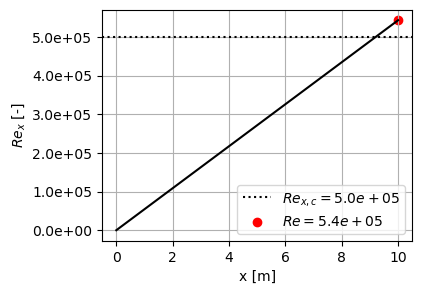

In [61]:
# calc Re
Re_xc = 5*10**5 # Incropera 6.24
u_inf = 1.0
L = 10.0 # 10.0 [m]
# nu = 15.89e-6 #0.001 #15.89e-6 # [m2/s] # kinematic visc aka momentum diffusivity
Re = u_inf*L/nu
# print('Re = {:.2e}'.format(Re))
# print('Re_x,c = {:.2e}'.format(Re_xc)) 

x = np.linspace(0,L,40)
Re_x = u_inf * x / nu

# Find x value where Re_x first exceeds Re_xc
index = np.argmax(Re_x > Re_xc)
x_critical = x[index] if np.any(Re_x > Re_xc) else None
print('x_c = {:2f} m'.format(x_critical))

fig, axs = plt.subplots(figsize=[4,3])
axs.plot(x, Re_x, 'k')
axs.axhline(Re_xc, color='k', linestyle=':', label=r'$Re_{{x,c}}= {:.1e}$'.format(Re_xc))
axs.scatter(L, Re, color='r', label='$Re = {:.1e}$'.format(Re))
axs.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1e'))
axs.legend()
axs.set_ylabel('$Re_x$ [-]')
axs.set_xlabel('x [m]')
axs.grid()

In [62]:
# dimensionless temperature
# Tstar = (T - T_s) / (T_inf - T_s) # Eq 6.33

In [ ]:
# Incropera solution to Laminar Flow over Isothermal Flat Plate
# Fig 7.4

# from table printed in text book
values = np.array([
    [0.0, 0.0,   0.0,   0.332],
    [0.4, 0.027, 0.133, 0.331],
    [0.8, 0.106, 0.265, 0.327],
    [1.2, 0.238, 0.394, 0.317],
    [1.6, 0.420, 0.517, 0.297],
    [2.0, 0.650, 0.630, 0.267],
    [2.4, 0.922, 0.729, 0.228],
    [2.8, 1.231, 0.812, 0.184],
    [3.2, 1.569, 0.876, 0.139],
    [3.6, 1.930, 0.923, 0.098],
    [4.0, 2.306, 0.956, 0.064],
    [4.4, 2.692, 0.976, 0.039],
    [4.8, 3.085, 0.988, 0.022],
    [5.2, 3.482, 0.994, 0.011],
    [5.6, 3.880, 0.997, 0.005],
    [6.0, 4.280, 0.999, 0.002],
    [6.4, 4.679, 1.000, 0.001],
    [6.8, 5.079, 1.000, 0.000]
])

# from webplotdigitizer
temp_values = pd.read_csv('wpd_datasets.csv')
temp_values

,X_Pr0_6,Pr0_6,X_Pr1,Pr1,X_Pr7,Pr7
0,0.046226,0.967887,0.012270,0.952670,0.006136,0.523210
1,0.065969,0.908921,0.018587,0.898934,0.020562,0.460648
2,0.085711,0.854234,0.030433,0.847101,0.050175,0.403055
3,0.109401,0.800770,0.050175,0.786708,0.089659,0.356606
4,0.139015,0.749140,0.071891,0.735270,0.133092,0.322021
5,0.174551,0.696831,0.101504,0.682037,0.176525,0.295651
6,0.216009,0.644522,0.139015,0.627640,0.219958,0.272090
7,0.259442,0.594374,0.180473,0.575569,0.263390,0.250475
8,0.302875,0.548334,0.223906,0.527583,0.306823,0.231021
9,0.346308,0.504671,0.267339,0.483920,0.350256,0.213512


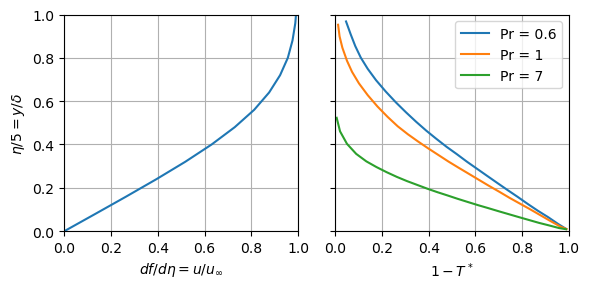

In [ ]:
# Incropera solution to Laminar Flow over Isothermal Flat Plate
# Fig 7.4

eta = values[:,0]
u_u_inf = values[:,2]

fig, axs = plt.subplots(1,2,figsize=[6,3],sharey=True)
axs[0].plot(u_u_inf, eta/5.0)
axs[0].set_ylabel('$\eta / 5 = y / \delta$')
axs[0].set_xlabel('$df/d\eta = u/u_{\infty}$')

axs[1].plot(temp_values['X_Pr0_6'],temp_values['Pr0_6'], label='Pr = 0.6')
axs[1].plot(temp_values['X_Pr1'],temp_values['Pr1'], label='Pr = 1')
axs[1].plot(temp_values['X_Pr7'],temp_values['Pr7'], label='Pr = 7')
axs[1].legend()
axs[1].set_xlabel('$1 - T^*$')

for ax in axs:
    ax.set_ylim([0,1])
    ax.set_xlim([0,1])
    ax.grid()

plt.tight_layout()

In [12]:
parentdir = '/Users/bstanisl/Documents/repos/PVade/output/heated_plate_2d/'
# filename = examples.download_meshio_xdmf(load=False)
filename = parentdir+'mesh/fluid_mesh.xdmf'
# filename = parentdir+'solution/solution_fluid.xdmf'

# reader = pv.get_reader(filename)
# print(filename.split("/")[-1])  # omit the path

# mesh = reader.read()
# mesh.plot()

xdmf_reader = pv.XdmfReader(filename)
mesh = xdmf_reader.read()
mesh.plot()

# # Access point data
# temperature_data = mesh.point_data["temperature"]
# print("Temperature data (first 5 values):", temperature_data[:5])

# # Access cell data
# pressure_data = mesh.cell_data["pressure"]
# print("Pressure data (first 5 values):", pressure_data[:5])

# # Clean up
# del reader

TypeError: 'NoneType' object is not iterable